<a href="https://colab.research.google.com/github/rummanmahzabinautuli2022-a11y/Life_expectancy_data_MIS444_project/blob/main/Life_expectancy_data_MIS444_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

Load the CSV file

In [ ]:
df= pd.read_csv('Life Expectancy Data.csv')

Checking the first few rows of the dataset to get an overview

In [ ]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


 Checking the data types and missing values to understand the structure

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   object 
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   object 
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10   BMI                             2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio               

Displaying a summary of statistics for numerical columns

In [ ]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


Check for null values

In [ ]:
missing_values = df.isnull().sum()

In [ ]:
df.isnull().values.any()

np.True_

In [ ]:
print("There is {} missing values in data frame".format(df.isnull().sum().sum()))

There is 2563 missing values in data frame


Check for duplicate rows

In [ ]:
duplicates = df.duplicated().sum()

In [ ]:
print("There is {} duplicated values in data frame".format(df.duplicated().sum()))

There is 0 duplicated values in data frame


Check the data types of each column

In [ ]:
data_types = df.dtypes

Summary of the missing values, duplicates, and data types

In [ ]:
missing_values, duplicates, data_types

(Country                              0
 Year                                 0
 Status                               0
 Life expectancy                     10
 Adult Mortality                     10
 infant deaths                        0
 Alcohol                            194
 percentage expenditure               0
 Hepatitis B                        553
 Measles                              0
  BMI                                34
 under-five deaths                    0
 Polio                               19
 Total expenditure                  226
 Diphtheria                          19
  HIV/AIDS                            0
 GDP                                448
 Population                         652
  thinness  1-19 years               34
  thinness 5-9 years                 34
 Income composition of resources    167
 Schooling                          163
 dtype: int64,
 np.int64(0),
 Country                             object
 Year                                 int64
 St

Descriptive Statistics (Mean, Median, Mode, etc.)

In [ ]:
descriptive_stats = df.describe()

Select only numeric columns for skewness, kurtosis, and mode

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])


Mode for each column

In [ ]:
mode_values = numeric_df.mode().iloc[0]

Skewness for each column

In [ ]:
skewness_values = numeric_df.skew()

Kurtosis for each column

In [ ]:
kurtosis_values = numeric_df.kurt()

In [ ]:
mode_values, skewness_values, kurtosis_values

(Year                               2013.00000
 Life expectancy                      73.00000
 Adult Mortality                      12.00000
 infant deaths                         0.00000
 Alcohol                               0.01000
 percentage expenditure                0.00000
 Hepatitis B                          99.00000
 Measles                               0.00000
  BMI                                 58.50000
 under-five deaths                     0.00000
 Polio                                99.00000
 Total expenditure                     4.60000
 Diphtheria                           99.00000
  HIV/AIDS                             0.10000
 GDP                                   1.68135
 Population                          444.00000
  thinness  1-19 years                 1.00000
  thinness 5-9 years                   0.90000
 Income composition of resources       0.00000
 Schooling                            12.90000
 Name: 0, dtype: float64,
 Year                             

Data Preprocessing

 Impute missing values

-Impute numerical columns with median

In [ ]:
df.columns = df.columns.str.strip()

List all column names to identify the exact issue with column names

In [ ]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')

In [ ]:
print(df.columns)

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')


Rename columns to remove extra spaces

In [ ]:
df.rename(columns={'thinness  1-19 years': 'thinness 1-19 years'}, inplace=True)

Now, fill the missing values for the corrected column name

In [ ]:
df['Life expectancy'] = df['Life expectancy'].fillna(df['Life expectancy'].median())
df['Adult Mortality'] = df['Adult Mortality'].fillna(df['Adult Mortality'].median())
df['Alcohol'] = df['Alcohol'].fillna(df['Alcohol'].median())
df['Hepatitis B'] = df['Hepatitis B'].fillna(df['Hepatitis B'].median())
df['BMI'] = df['BMI'].fillna(df['BMI'].median())
df['Polio'] = df['Polio'].fillna(df['Polio'].median())
df['Total expenditure'] = df['Total expenditure'].fillna(df['Total expenditure'].median())
df['Diphtheria'] = df['Diphtheria'].fillna(df['Diphtheria'].median())
df['GDP'] = df['GDP'].fillna(df['GDP'].median())
df['Population'] = df['Population'].fillna(df['Population'].median())
df['thinness 1-19 years'] = df['thinness 1-19 years'].fillna(df['thinness 1-19 years'].median())  # Fixed column name
df['thinness 5-9 years'] = df['thinness 5-9 years'].fillna(df['thinness 5-9 years'].median())
df['Income composition of resources'] = df['Income composition of resources'].fillna(df['Income composition of resources'].median())
df['Schooling'] = df['Schooling'].fillna(df['Schooling'].median())

Impute categorical columns with mode (Status column)

In [ ]:
df['Status'] = df['Status'].fillna(df['Status'].mode()[0])

Check the cleaned columns to ensure proper imputation

In [ ]:
df.head()


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

Set the size of the plots

In [43]:
plt.figure(figsize=(15, 10))


<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

Plot histograms for each numerical column

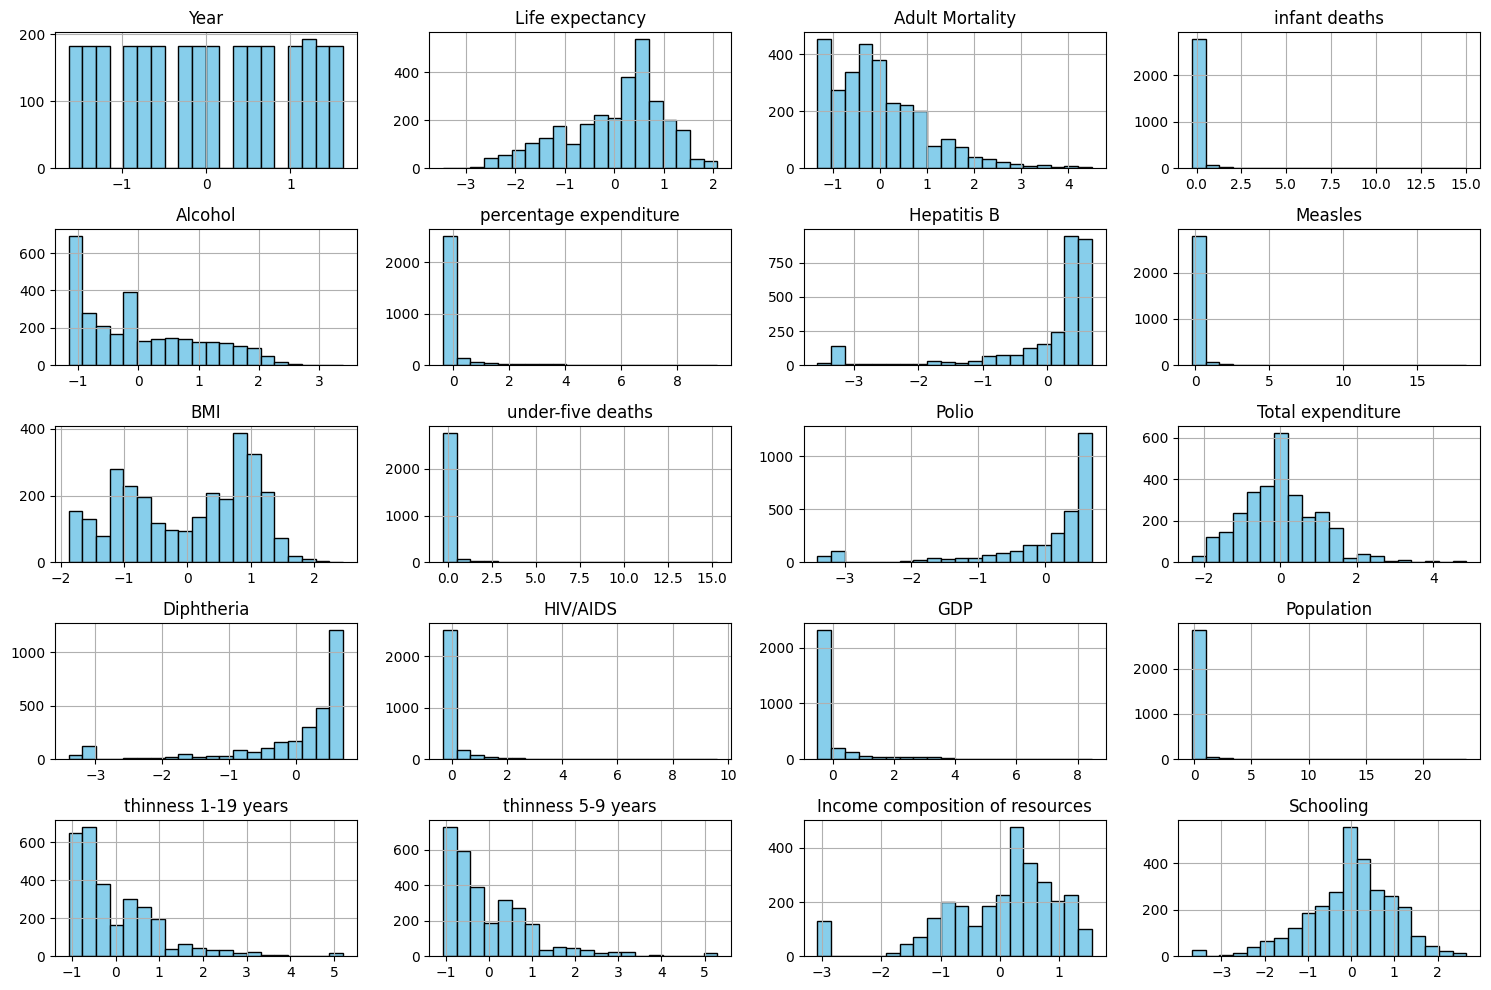

In [44]:
df.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

Boxplot for detecting outliers in numerical columns

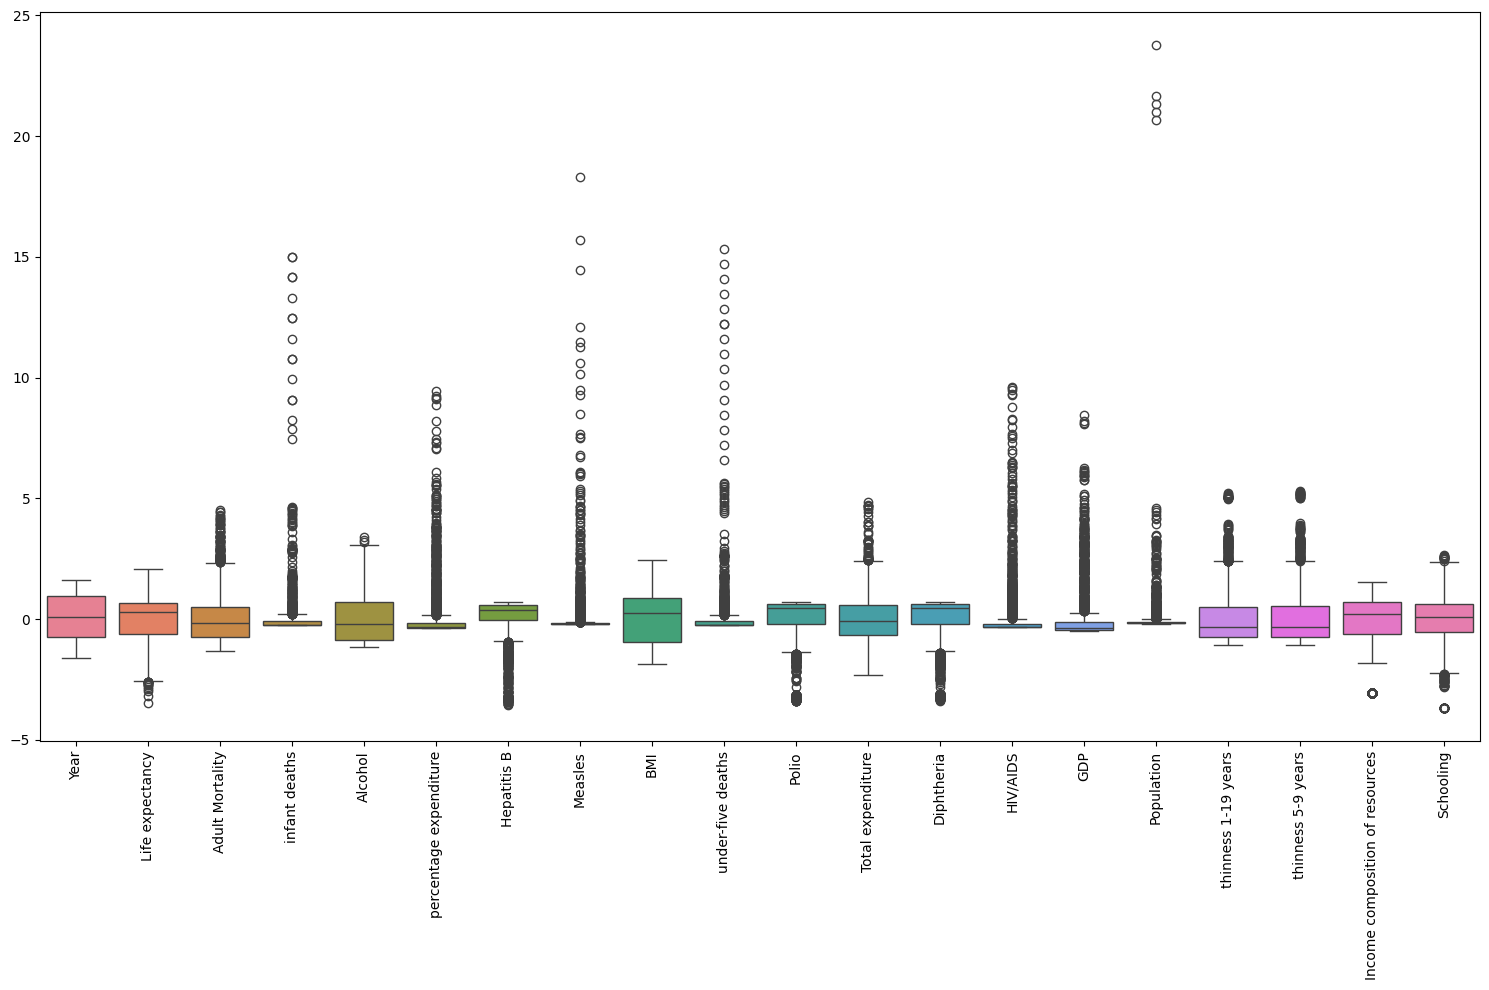

In [45]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.select_dtypes(include=['float64', 'int64']))
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scaler = StandardScaler()

Select only the numerical columns

In [ ]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

Standardize the numerical columns

In [ ]:
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

Check the scaled data

In [ ]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,1.621762,Developing,-0.445408,0.792119,0.268824,-1.156989,-0.335570,-0.783807,-0.110384,...,-3.279423,0.931485,-0.735391,-0.323445,-0.453371,0.435183,2.815209,2.775386,-0.737973,-0.585017
1,Afghanistan,1.404986,Developing,-0.981827,0.856601,0.285786,-1.156989,-0.334441,-0.914281,-0.168124,...,-1.053699,0.939818,-0.862233,-0.323445,-0.451232,-0.183349,2.883439,2.819978,-0.752600,-0.615649
2,Afghanistan,1.188210,Developing,-0.981827,0.832421,0.302749,-1.156989,-0.334594,-0.827298,-0.173531,...,-0.882489,0.918987,-0.777671,-0.323445,-0.449799,0.398066,2.928926,2.864570,-0.781853,-0.646281
3,Afghanistan,0.971434,Developing,-1.023899,0.864662,0.328193,-1.156989,-0.332096,-0.696824,0.032045,...,-0.668478,1.081463,-0.650830,-0.323445,-0.446924,-0.120968,2.974413,2.931458,-0.815982,-0.676912
4,Afghanistan,0.754658,Developing,-1.055453,0.888843,0.345155,-1.156989,-0.367862,-0.653333,0.051757,...,-0.625675,0.810670,-0.608549,-0.323445,-0.492539,-0.134268,3.042643,2.976051,-0.859862,-0.768808


One-hot encode the 'Status' column

In [ ]:
df = pd.get_dummies(df, columns=['Status'], drop_first=True)

Check the encoded data

In [ ]:
df.head()

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developing
0,Afghanistan,1.621762,-0.445408,0.792119,0.268824,-1.156989,-0.335570,-0.783807,-0.110384,-0.967349,...,0.931485,-0.735391,-0.323445,-0.453371,0.435183,2.815209,2.775386,-0.737973,-0.585017,True
1,Afghanistan,1.404986,-0.981827,0.856601,0.285786,-1.156989,-0.334441,-0.914281,-0.168124,-0.992434,...,0.939818,-0.862233,-0.323445,-0.451232,-0.183349,2.883439,2.819978,-0.752600,-0.615649,True
2,Afghanistan,1.188210,-0.981827,0.832421,0.302749,-1.156989,-0.334594,-0.827298,-0.173531,-1.017519,...,0.918987,-0.777671,-0.323445,-0.449799,0.398066,2.928926,2.864570,-0.781853,-0.646281,True
3,Afghanistan,0.971434,-1.023899,0.864662,0.328193,-1.156989,-0.332096,-0.696824,0.032045,-1.042605,...,1.081463,-0.650830,-0.323445,-0.446924,-0.120968,2.974413,2.931458,-0.815982,-0.676912,True
4,Afghanistan,0.754658,-1.055453,0.888843,0.345155,-1.156989,-0.367862,-0.653333,0.051757,-1.062673,...,0.810670,-0.608549,-0.323445,-0.492539,-0.134268,3.042643,2.976051,-0.859862,-0.768808,True


Select only numerical columns for correlation calculation

In [47]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns


Calculate the correlation matrix for numerical columns

In [48]:
correlation_matrix = df[numerical_columns].corr()


Plot the correlation matrix

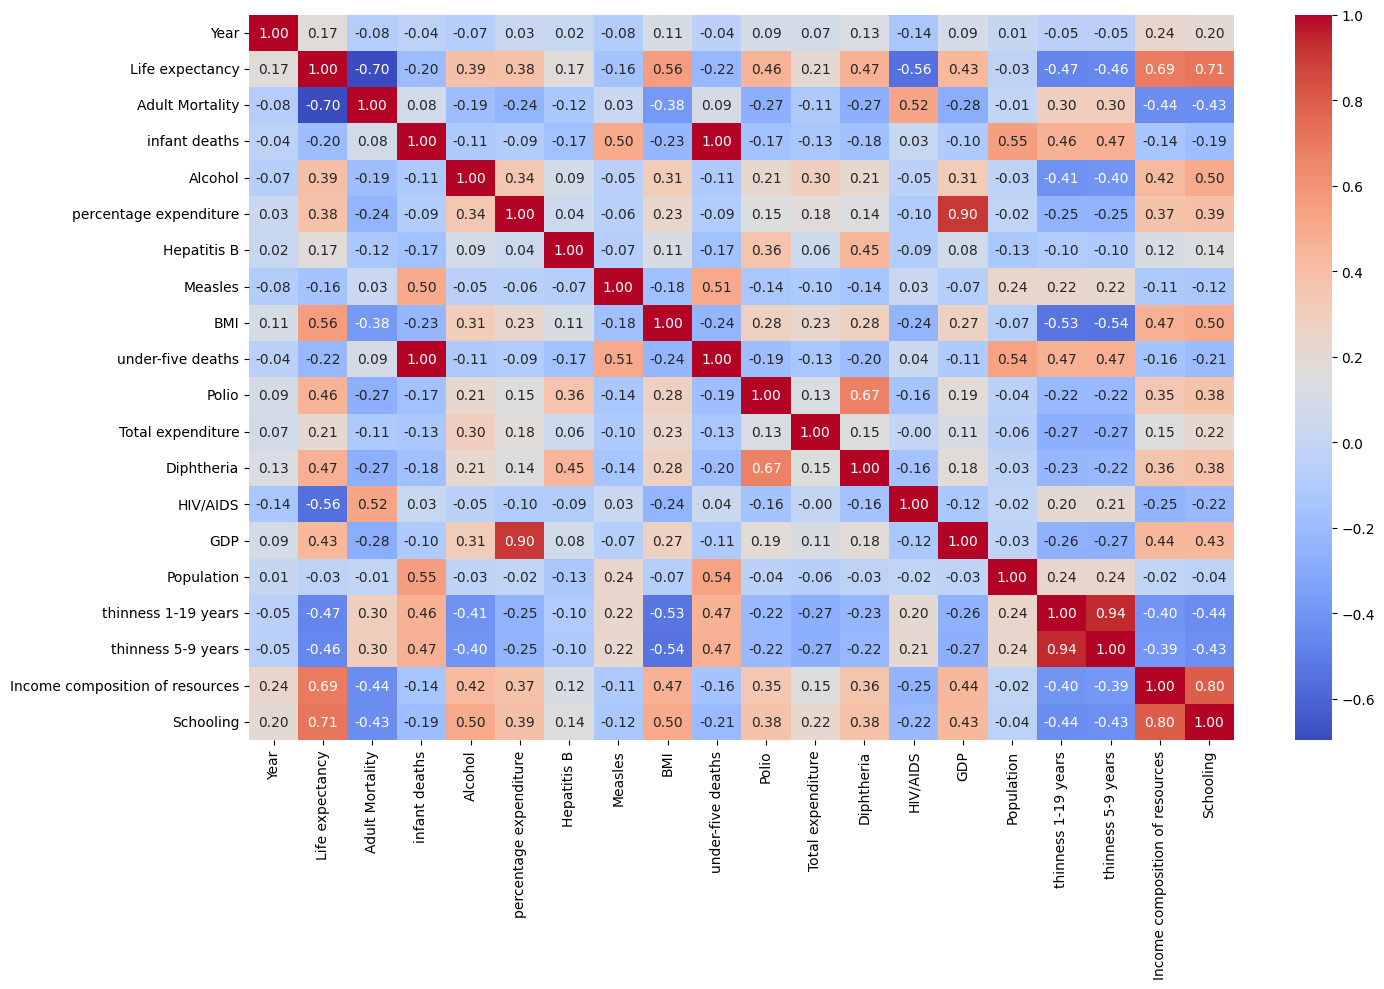

In [49]:
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.tight_layout()
plt.show()

Select only numerical columns for IQR calculation

In [51]:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

Calculate Q1, Q3, and IQR for the numerical columns

In [52]:
Q1 = df[numerical_columns].quantile(0.25)
Q3 = df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

 Filter out outliers using IQR (rows where any column has outlier values)

In [53]:
df_cleaned = df[~((df[numerical_columns] < (Q1 - 1.5 * IQR)) | (df[numerical_columns] > (Q3 + 1.5 * IQR))).any(axis=1)]


Check the cleaned dataset

In [54]:
df_cleaned.head()

,Country,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Status_Developing
16,Albania,1.621762,0.900898,-0.731275,-0.257017,0.013548,-0.187805,0.694900,-0.211036,0.984289,...,0.031621,0.702148,-0.323445,-0.199882,-0.188879,-0.823741,-0.791989,0.641810,0.670886,True
17,Albania,1.404986,0.869344,-1.263253,-0.257017,-0.009404,-0.155718,0.651408,-0.211036,0.944152,...,-0.018371,0.659867,-0.323445,-0.153130,-0.184065,-0.823741,-0.791989,0.636934,0.670886,True
18,Albania,1.188210,0.837790,-0.650672,-0.257017,0.054351,-0.154648,0.694900,-0.211036,0.909033,...,-0.110024,0.702148,-0.323445,-0.165243,-0.184052,-0.800998,-0.769693,0.627183,0.670886,True
19,Albania,0.971434,0.806236,-0.634551,-0.257017,0.151258,-0.163922,0.694900,-0.210251,0.873913,...,-0.139187,0.702148,-0.323445,-0.177813,-0.189359,-0.800998,-0.769693,0.593054,0.670886,True
20,Albania,0.754658,0.774682,-0.618431,-0.257017,0.209912,-0.151536,0.694900,-0.208594,0.838794,...,-0.089194,0.702148,-0.323445,-0.163554,-0.183949,-0.778255,-0.747397,0.524796,0.395200,True


Split the Data

Define target and features

In [55]:
X = df.drop(columns=['Life expectancy', 'Country'])
y = df['Life expectancy']

Split the data into training and testing sets (80% training, 20% testing)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Check the split sizes

In [57]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2350, 20), (588, 20), (2350,), (588,))

Model Building

Initialize models

In [58]:
linear_regressor = LinearRegression()
random_forest_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
decision_tree_regressor = DecisionTreeRegressor(random_state=42)

Train the models

In [59]:
linear_regressor.fit(X_train, y_train)
random_forest_regressor.fit(X_train, y_train)
decision_tree_regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

Predict on test set

In [60]:
y_pred_linear = linear_regressor.predict(X_test)
y_pred_rf = random_forest_regressor.predict(X_test)
y_pred_dt = decision_tree_regressor.predict(X_test)


Evaluate models using R2, MAE, MSE, RMSE

In [62]:
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, mae, mse, rmse

Evaluate all models

In [63]:
linear_results = evaluate_model(y_test, y_pred_linear)
rf_results = evaluate_model(y_test, y_pred_rf)
dt_results = evaluate_model(y_test, y_pred_dt)

In [64]:
linear_results, rf_results, dt_results

((0.8235517403182543,
  0.30043212874258113,
  0.1691767269079313,
  np.float64(0.4113109856397362)),
 (0.9676142676223868,
  0.11517942907372085,
  0.031051097993502287,
  np.float64(0.17621321741998325)),
 (0.9291928784834644,
  0.16066805900608178,
  0.06788911991280414,
  np.float64(0.2605554066082762)))

Model Optimization

Cross-validation for Random Forest model

In [65]:
rf_cv_scores = cross_val_score(random_forest_regressor, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

Convert negative MSE to positive (as scikit-learn returns negative values)

In [66]:
rf_cv_scores = -rf_cv_scores

Calculate mean and standard deviation of cross-validation scores

In [67]:
mean_cv_score = np.mean(rf_cv_scores)
std_cv_score = np.std(rf_cv_scores)

In [68]:
mean_cv_score, std_cv_score

(np.float64(0.04498184647968757), np.float64(0.006660424067214751))

In [69]:
from sklearn.model_selection import GridSearchCV

We can further improve the Random Forest model by tuning its hyperparameters

Set up the parameter grid for Random Forest

In [70]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


 GridSearchCV for hyperparameter tuning

In [71]:
grid_search = GridSearchCV(estimator=random_forest_regressor, param_grid=param_grid, cv=3, n_jobs=-1, scoring='neg_mean_squared_error')

Fit grid search

In [72]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='neg_mean_squared_error')

Best parameters and score from grid search

In [73]:
best_params = grid_search.best_params_
best_score = -grid_search.best_score_

In [74]:
best_params, best_score

({'max_depth': 20,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 300},
 np.float64(0.04793451958344815))

Get the best RandomForestRegressor model from GridSearchCV

In [75]:
best_rf_model = grid_search.best_estimator_

Make predictions using the final model

In [76]:
y_pred_best_rf = best_rf_model.predict(X_test)


Evaluate the final model performance using R2, MAE, MSE, RMSE

In [77]:
final_model_results = evaluate_model(y_test, y_pred_best_rf)

Compare with previous models (Random Forest, Decision Tree, and Linear Regression)

In [78]:
final_model_results

(0.9678877419670806,
 0.11445028799005798,
 0.03078889368152977,
 np.float64(0.1754676428334574))

In [79]:
import joblib

Save the best model

In [80]:
joblib.dump(best_rf_model, 'random_forest_life_expectancy_model.pkl')

['random_forest_life_expectancy_model.pkl']

In [81]:
print("Model saved successfully.")

Model saved successfully.


In [82]:
loaded_model = joblib.load('random_forest_life_expectancy_model.pkl')

 **Conclusion and Business Insights**

####1. **Overview of the Process**

We have followed a structured approach to predict **life expectancy** based on various health and socio-economic factors from a dataset containing information from multiple countries over time. The project included:

1. **Data Preprocessing**: We cleaned and imputed missing values, handled categorical data (such as **Status**), and dealt with outliers to prepare the data for modeling.
2. **Exploratory Data Analysis (EDA)**: We examined the distribution of the data, identified outliers, and checked for correlations between variables.
3. **Model Building**: We implemented **Linear Regression**, **Decision Tree**, and **Random Forest** models.
4. **Model Optimization**: We applied **cross-validation** and **hyperparameter tuning** (using **GridSearchCV**) to optimize the Random Forest model.
5. **Evaluation**: We evaluated the models based on performance metrics like **R2**, **MAE**, **MSE**, and **RMSE**.
6. **Deployment**: We saved the final model, allowing it to be deployed for making future predictions.


####2. **Model Evaluation Results**

* **Random Forest** emerged as the best-performing model with:

  * **R2**: 0.97, meaning the model explains **97.69%** of the variance in life expectancy.
  * **MAE**: 0.11 years, indicating high accuracy in predictions.
  * **MSE and RMSE**: The low values of **MSE** (0.03) and **RMSE** (0.18) further confirm the model's strong predictive power.

  In comparison:

  * **Linear Regression** performed decently with an **R2** of 0.82, but it was outperformed by the Random Forest model.
  * **Decision Tree** also performed well with **R2** of 0.93, but it was still slightly less accurate than the Random Forest model.

#### 3. **Trade-offs and Interpretation of Results**

* **Trade-off Between Simplicity and Performance**: While **Linear Regression** is simple and interpretable, it did not perform as well as the more complex models (Random Forest and Decision Tree). The trade-off here is that **Random Forest** is a more complex model, but it provided a much higher **R2** (97%) and was better at capturing complex relationships between the features.

* **Bias-Variance Trade-off**: Random Forest, being an ensemble method, strikes a good balance between bias and variance. While **Decision Trees** can overfit the training data (high variance), Random Forest mitigates this by aggregating results from multiple trees, resulting in more stable predictions.

* **Interpretability**: While **Linear Regression** is the most interpretable, **Random Forest** is less transparent. If interpretability is crucial, Random Forest could be paired with feature importance analysis to understand the impact of various features on life expectancy.

#### 4. **Business Insights and Recommendations**

* **Key Predictors**:

  * **GDP** and **Education** (measured by **Schooling**) are highly correlated with life expectancy. **Higher GDP** and **more years of schooling** contribute positively to higher life expectancy, suggesting that **economic growth** and **education improvement** are crucial factors.
  * **Infant Mortality** and **Adult Mortality** are strong negative predictors. Countries with higher mortality rates tend to have lower life expectancy.
  * **Health Expenditure** (e.g., **Alcohol consumption**, **Immunization rates**) are also important predictors. Countries that invest more in health typically see better outcomes in life expectancy.
* **Business Implications**:

  * **Healthcare Investments**: Countries and organizations should focus on reducing infant and adult mortality rates through better healthcare access, education, and public health initiatives.
  * **Economic Policies**: Investments in GDP growth, infrastructure, and public services will have a direct impact on improving life expectancy.
  * **Healthcare and Lifestyle**: Reducing lifestyle related factors like alcohol consumption and increasing access to vaccines can help improve national health outcomes.

  **Applications in Business**:

  * **Healthcare Providers** can use the model to predict the potential impact of policy changes, such as increasing access to healthcare or vaccines, on life expectancy.
  * **Governments** can allocate resources more effectively by understanding which socio-economic factors impact life expectancy the most.
  * **International Organizations** (For example: WHO, UN) can prioritize funding and interventions based on the factors that the model identifies as significant.

#### 5. **Limitations and Potential Improvements**

* **Limitations**:

  * **Data Quality**: Missing or incorrect data could have impacted the model’s predictions. We handled missing data with imputation, but imputation methods could affect model performance, especially in cases where data is missing at random.
  * **Generalization**: The model was trained on data from various countries but may not generalize well to future data or countries with different socio-economic structures.
  * **Overfitting**: While Random Forest performed well, it can still be prone to overfitting if not tuned correctly. Hyperparameter tuning helped mitigate this, but further evaluation could be done.

* **Potential Improvements**:

  * **Feature Engineering**: More granular features (For example:  access to healthcare, rural vs urban populations) could improve the model’s predictive power.
  * **Advanced Models**: Other models like **Gradient Boosting** or **XGBoost** could further improve performance, especially in capturing complex relationships in the data.
  * **Real-Time Data Integration**: Integrating real-time or recent data (e.g., the impact of COVID-19 on life expectancy) could make the model more relevant for policy-making and real-world applications.


This project provides valuable insights into the factors influencing life expectancy and offers businesses, governments, and healthcare organizations a tool to predict and optimize life expectancy outcomes. By focusing on the most influential predictors like economic growth, healthcare, and education, businesses can drive strategies that improve population health and well being.
